# Car Damage Training — Kaggle 
## YOLOv8n Detector Training

In [17]:
!pip install ultralytics -q

# 1.VERIFYING THE NUMBER OF IMAGES 


Training Images   : 2816
Validation Images : 810
Testing Images    : 374
Total Images      : 4000


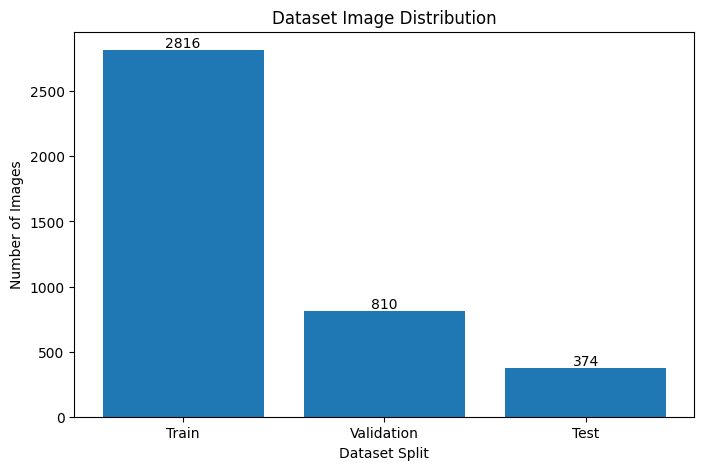

In [1]:
import os
import matplotlib.pyplot as plt

# Dataset path
base_path = "/kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset"

# Folder paths
train_folder = os.path.join(base_path, "train/images")
val_folder   = os.path.join(base_path, "val/images")
test_folder  = os.path.join(base_path, "test/images")

# Supported image formats
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

# Function to count images
def count_images(folder):
    return sum(
        1 for file in os.listdir(folder)
        if file.lower().endswith(image_extensions)
    )

# Count images
train_count = count_images(train_folder)
val_count   = count_images(val_folder)
test_count  = count_images(test_folder)

# Total count
total_images = train_count + val_count + test_count

# Print results
print(f"Training Images   : {train_count}")
print(f"Validation Images : {val_count}")
print(f"Testing Images    : {test_count}")
print(f"Total Images      : {total_images}")

# Data for graph
categories = ["Train", "Validation", "Test"]
counts = [train_count, val_count, test_count]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts)

# Add labels and title
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Image Distribution")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

# Show graph
plt.show()

# 2.VERIFYING NUMBER OF INSTANCES

 Training Instances 
dent: 1806
scratch: 2560
tire flat: 225
glass shatter: 475
crack: 651
lamp broken: 494
Total Training   : 6211

 Validation Instances 
scratch: 728
dent: 501
lamp broken: 141
tire flat: 62
crack: 177
glass shatter: 135
Validation : 1744

 Testing Instances 
dent: 236
scratch: 307
crack: 70
lamp broken: 69
tire flat: 32
glass shatter: 71
Testing    : 785


Overall Instances   : 8740





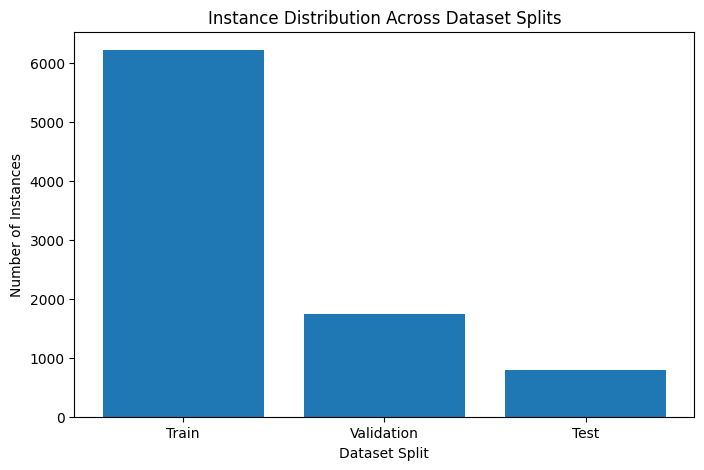

In [6]:
from collections import Counter
import glob
import os
import matplotlib.pyplot as plt

# Dataset paths
base_path = "/kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset"

train_labels = os.path.join(base_path, "train/labels/*.txt")
val_labels   = os.path.join(base_path, "val/labels/*.txt")
test_labels  = os.path.join(base_path, "test/labels/*.txt")

# Class names
classes = {
    0: "dent",
    1: "scratch",
    2: "crack",
    3: "glass shatter",
    4: "lamp broken",
    5: "tire flat"
}

# Function to count instances
def count_instances(label_path):
    
    counter = Counter()

    for file in glob.glob(label_path):

        with open(file, "r") as f:

            for line in f:

                class_id = int(line.split()[0])
                counter[class_id] += 1

    return counter

# Count instances
train_counter = count_instances(train_labels)
val_counter   = count_instances(val_labels)
test_counter  = count_instances(test_labels)

total_train = sum(train_counter.values())
total_val   = sum(val_counter.values())
total_test  = sum(test_counter.values())
# Print results
print(" Training Instances ")
for cid, count in train_counter.items():
    print(f"{classes[cid]}: {count}")
print(f"Total Training   : {total_train}")

print("\n Validation Instances ")
for cid, count in val_counter.items():
    print(f"{classes[cid]}: {count}")
print(f"Validation : {total_val}")

print("\n Testing Instances ")
for cid, count in test_counter.items():
    print(f"{classes[cid]}: {count}")
print(f"Testing    : {total_test}")

print(f"\n\nOverall Instances   : {total_train + total_val + total_test}")

# Plotting
print(f"\n\n")
folders = ["Train", "Validation", "Test"]
totals = [total_train, total_val, total_test]

plt.figure(figsize=(8,5))
plt.bar(folders, totals)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Instances")
plt.title("Instance Distribution Across Dataset Splits")

plt.show()

# 3.CLASS DISTRIBUTION

=== Training Set ===
dent: 1806
scratch: 2560
tire_flat: 225
glass_shatter: 475
crack: 651
lamp_broken: 494

=== Validation Set ===
scratch: 728
dent: 501
lamp_broken: 141
tire_flat: 62
crack: 177
glass_shatter: 135

=== Testing Set ===
dent: 236
scratch: 307
crack: 70
lamp_broken: 69
tire_flat: 32
glass_shatter: 71


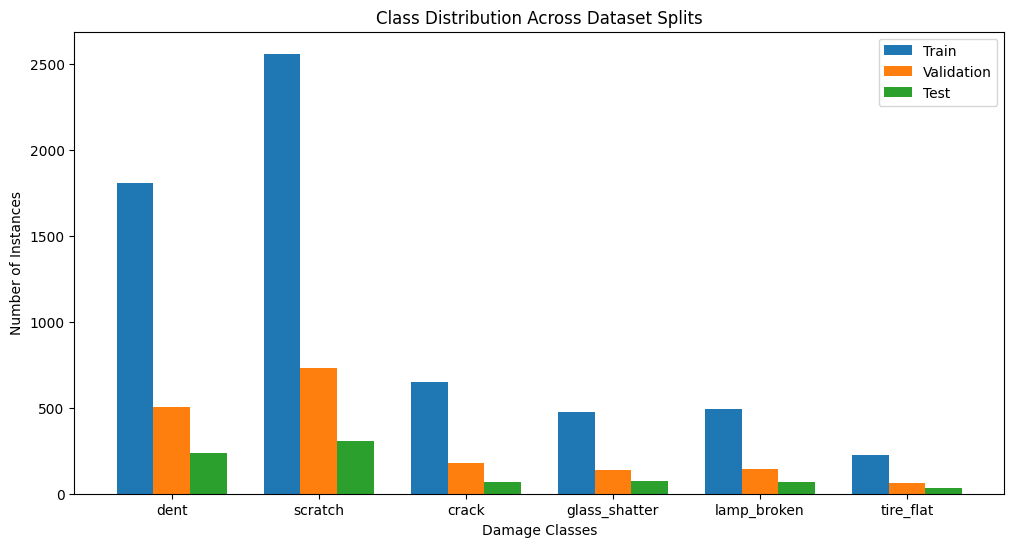

In [10]:
import os
from collections import Counter
import matplotlib.pyplot as plt

# Dataset base path
base_path = "/kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset"

# Label folders
train_path = os.path.join(base_path, "train/labels")
val_path   = os.path.join(base_path, "val/labels")
test_path  = os.path.join(base_path, "test/labels")

# Class names
classes = {
    0: "dent",
    1: "scratch",
    2: "crack",
    3: "glass_shatter",
    4: "lamp_broken",
    5: "tire_flat"
}

# Function to count class instances
def count_classes(label_path):

    counter = Counter()

    for file in os.listdir(label_path):

        if file.endswith(".txt"):

            with open(os.path.join(label_path, file), "r") as f:

                for line in f:

                    class_id = int(line.split()[0])
                    counter[class_id] += 1

    return counter

# Count distributions
train_counter = count_classes(train_path)
val_counter   = count_classes(val_path)
test_counter  = count_classes(test_path)

# -----------------------------
# Print Results
# -----------------------------

print("=== Training Set ===")
for cid, count in train_counter.items():
    print(f"{classes[cid]}: {count}")

print("\n=== Validation Set ===")
for cid, count in val_counter.items():
    print(f"{classes[cid]}: {count}")

print("\n=== Testing Set ===")
for cid, count in test_counter.items():
    print(f"{classes[cid]}: {count}")

# -----------------------------
# Plotting
# -----------------------------

class_labels = list(classes.values())

train_counts = [train_counter[i] for i in range(len(classes))]
val_counts   = [val_counter[i] for i in range(len(classes))]
test_counts  = [test_counter[i] for i in range(len(classes))]

x = range(len(class_labels))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar([i - width for i in x], train_counts, width=width, label='Train')
plt.bar(x, val_counts, width=width, label='Validation')
plt.bar([i + width for i in x], test_counts, width=width, label='Test')

plt.xticks(x, class_labels)

plt.xlabel("Damage Classes")
plt.ylabel("Number of Instances")
plt.title("Class Distribution Across Dataset Splits")

plt.legend()

plt.show()

# 4.VERIFYING ALL THE ANNOTATIONS

In [7]:
import os

base_path = "/kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset"

# Label folders
folders = {
    "Train": os.path.join(base_path, "train/labels"),
    "Validation": os.path.join(base_path, "val/labels"),
    "Test": os.path.join(base_path, "test/labels")
}

all_correct = True

# Check each folder
for folder_name, label_path in folders.items():

    print(f"\nChecking {folder_name} Labels...\n")

    folder_correct = True

    for file in os.listdir(label_path):

        if file.endswith(".txt"):

            file_path = os.path.join(label_path, file)

            with open(file_path, "r") as f:

                for line_num, line in enumerate(f, start=1):

                    parts = line.strip().split()

                    # Check annotation format
                    if len(parts) != 5:
                        print(f"Invalid format in {file}, line {line_num}")
                        all_correct = False
                        folder_correct = False
                        continue

                    class_id, x, y, w, h = map(float, parts)

                    # Check invalid width or height
                    if w <= 0 or h <= 0:
                        print(f"Invalid bbox in {file}, line {line_num}")
                        all_correct = False
                        folder_correct = False

                    # Check normalized values
                    if not (
                        0 <= x <= 1 and
                        0 <= y <= 1 and
                        0 <= w <= 1 and
                        0 <= h <= 1
                    ):
                        print(f"Out-of-range values in {file}, line {line_num}")
                        all_correct = False
                        folder_correct = False

    # Folder summary
    if folder_correct:
        print(f"All {folder_name} annotation files are valid.\n")
    else:
        print(f"Some errors found in {folder_name} annotations.\n")

if all_correct:
    print("All YOLO annotation files across Train, Validation, and Test sets are valid and correctly formatted.")
else:
    print("Some annotation errors were found in the dataset.")


Checking Train Labels...

All Train annotation files are valid.


Checking Validation Labels...

All Validation annotation files are valid.


Checking Test Labels...

All Test annotation files are valid.

All YOLO annotation files across Train, Validation, and Test sets are valid and correctly formatted.


# 5.Install & Setup

In [25]:
#!pip install ultralytics -q

import os, shutil, yaml, glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# YOLO CONFIGURATION FOR FIRST TRAINING
EPOCHS      = 100
IMG_SIZE    = 640
BATCH       = 16
PATIENCE    = 20
SAVE_PERIOD = 5

DET_ROOT   = '/kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset'
CROPS_ROOT = '/kaggle/input/datasets/syedazhaanali/segmentation-crop-dataset/segmentation_crops_dataset'
WORK_DIR   = '/kaggle/working'

assert os.path.exists(DET_ROOT),   f'Not found: {DET_ROOT}'
assert os.path.exists(CROPS_ROOT), f'Not found: {CROPS_ROOT}'

print('Both datasets mounted')
for root, name in [(DET_ROOT, 'Detection'), (CROPS_ROOT, 'Crops')]:
    for split in ['train', 'val', 'test']:
        p = Path(root, split, 'images')
        n = len(list(p.glob('*'))) if p.exists() else 0
        print(f'   {name:10s} [{split}]: {n} images')

✅ Both datasets mounted
   Detection  [train]: 2816 images
   Detection  [val]: 810 images
   Detection  [test]: 374 images
   Crops      [train]: 5990 images
   Crops      [val]: 1694 images
   Crops      [test]: 765 images


# 6.Fix YAML Paths

The `data.yaml` files were created in Colab with `path: /content/`.
We rewrite them here to point to `/kaggle/input/` before training.

In [28]:
def fix_yaml(src_path, correct_root, out_path):
    with open(src_path) as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = correct_root
    with open(out_path, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)
    print(f'{out_path}')
    for k in ['path', 'train', 'val', 'test', 'nc', 'names']:
        if k in cfg:
            print(f'   {k}: {cfg[k]}')
    return out_path

DET_YAML   = fix_yaml(f'{DET_ROOT}/data.yaml',   DET_ROOT,   f'{WORK_DIR}/detection.yaml')
CROPS_YAML = fix_yaml(f'{CROPS_ROOT}/data.yaml', CROPS_ROOT, f'{WORK_DIR}/segmentation_crops.yaml')

✅ /kaggle/working/detection.yaml
   path: /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset
   train: train/images
   val: val/images
   test: test/images
   nc: 6
   names: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
✅ /kaggle/working/segmentation_crops.yaml
   path: /kaggle/input/datasets/syedazhaanali/segmentation-crop-dataset/segmentation_crops_dataset
   train: train/images
   val: val/images
   test: test/images
   nc: 6
   names: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}


# 7.Train YOLOv8n Detector

In [3]:
DET_LAST = f'{WORK_DIR}/runs/detect/weights/last.pt'
DET_BEST = f'{WORK_DIR}/runs/detect/weights/best.pt'

if os.path.exists(DET_LAST):
    print(f'Resuming from checkpoint: {DET_LAST}')
    detector = YOLO(DET_LAST)
    detector.train(resume=True)
else:
    print('Starting detector training from scratch...')
    detector = YOLO('yolov8n.pt')
    detector.train(
        data        = DET_YAML,
        epochs      = EPOCHS,
        imgsz       = IMG_SIZE,
        batch       = BATCH,
        patience    = PATIENCE,
        save        = True,
        save_period = SAVE_PERIOD,
        project     = f'{WORK_DIR}/runs',
        name        = 'detect',
        plots       = True,
        verbose     = True,
    )

print(f'\n✅ Done  →  best weights: {DET_BEST}')

🚀 Starting detector training from scratch...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/detection.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

# 8.Evaluate Detector

In [7]:
detector = YOLO(DET_BEST)
m = detector.val(data=DET_YAML)
print(f'mAP50    : {m.box.map50:.4f}')
print(f'mAP50-95 : {m.box.map:.4f}')
print(f'Precision: {m.box.mp:.4f}')
print(f'Recall   : {m.box.mr:.4f}')

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1244.1±321.4 MB/s, size: 683.4 KB)
val: Scanning /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/val/labels... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 1.2Kit/s 0.7s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 6.7it/s 7.6s0.1s
                   all        810       1744      0.769      0.686      0.719      0.571
                  dent        352        501      0.701      0.515      0.595      0.332
               scratch        431        728      0.618      0.526      0.531      0.297
                 crack     

In [9]:
# ── Detection Test Results ────────────────────────────────────────────
print('Detection Test Results:')
detector = YOLO(DET_BEST)
det_metrics = detector.val(data=DET_YAML, split='test')

print(f'   mAP50      : {det_metrics.box.map50:.4f}')
print(f'   mAP50-95   : {det_metrics.box.map:.4f}')
print(f'   Precision  : {det_metrics.box.mp:.4f}')
print(f'   Recall     : {det_metrics.box.mr:.4f}')

📊 Detection Test Results:
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 39.8±29.0 MB/s, size: 639.0 KB)
val: Scanning /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/test/labels... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 105.0it/s 3.6s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 5.3it/s 4.5s0.2s
                   all        374        785      0.731      0.678      0.723      0.568
                  dent        157        236      0.688      0.576      0.629      0.363
               scratch        183        307      0.585       0.55      0.579      0.317
  

In [16]:
import shutil

shutil.make_archive('/kaggle/working/runsFT1_backup', 'zip', '/kaggle/working', 'runs')
print(f"runs_backup.zip created")

✅ runs_backup.zip created


In [2]:
import shutil

shutil.copytree(
    '/kaggle/input/models/syedazhaanali/ft1-yolo-detect/other/default/1',
    '/kaggle/working/ft1-yolo-detect'
)
print('Runs folder copied to /kaggle/working/runs')

✅ Runs folder copied to /kaggle/working/runs


# 9.Fine-Tuning Detector

In [11]:
detector = YOLO("/kaggle/working/yolomodels-t1/runs/detect/weights/best.pt")   # starting from best checkpoint
detector.train(
    data        = DET_YAML,
    epochs      = 50,        # fewer epochs for fine-tuning
    imgsz       = 832,       # larger image size helps crack/scratch detection
    batch       = 8,         # reduce batch for larger image size
    lr0         = 0.001,     # lower learning rate for fine-tuning
    patience    = 15,
    save        = True,
    save_period = 5,
    project     = f'{WORK_DIR}/runs',
    name        = 'detect_finetune1',
)



FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/yolomodels-t1/runs/detect/weights/best.pt'

# 10.Evaluating Detector

In [29]:
#Evaluate FineTune Detector-1
detector = YOLO("/kaggle/input/models/syedazhaanali/ft1-yolo-detect/other/default/1/runs/detect_finetune1/weights/best.pt") 
m = detector.val(data=DET_YAML)
print(f'mAP50    : {m.box.map50:.4f}')
print(f'mAP50-95 : {m.box.map:.4f}')
print(f'Precision: {m.box.mp:.4f}')
print(f'Recall   : {m.box.mr:.4f}')

detector = YOLO("/kaggle/input/models/syedazhaanali/ft1-yolo-detect/other/default/1/runs/detect_finetune1/weights/best.pt")
det_metrics = detector.val(data=DET_YAML, split='test')

print(f'   mAP50      : {det_metrics.box.map50:.4f}')
print(f'   mAP50-95   : {det_metrics.box.map:.4f}')
print(f'   Precision  : {det_metrics.box.mp:.4f}')
print(f'   Recall     : {det_metrics.box.mr:.4f}')

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.9±19.7 MB/s, size: 791.4 KB)
val: Scanning /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/val/labels... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 165.1it/s 4.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 3.5s/it 2:593.9ss
                   all        810       1744      0.762       0.69      0.718      0.549
                  dent        352        501      0.688      0.484      0.554      0.288
               scratch        431        728      0.617      0.518      0.533      0.286
                 crack      

In [15]:

#Evaluate FineTune Detector-1
detector = YOLO("/kaggle/working/runs/detect_finetune1/weights/best.pt") 
m = detector.val(data=DET_YAML)
print(f'mAP50    : {m.box.map50:.4f}')
print(f'mAP50-95 : {m.box.map:.4f}')
print(f'Precision: {m.box.mp:.4f}')
print(f'Recall   : {m.box.mr:.4f}')
detector = YOLO("/kaggle/working/runs/detect_finetune1/weights/best.pt")
det_metrics = detector.val(data=DET_YAML, split='test')

print(f'   mAP50      : {det_metrics.box.map50:.4f}')
print(f'   mAP50-95   : {det_metrics.box.map:.4f}')
print(f'   Precision  : {det_metrics.box.mp:.4f}')
print(f'   Recall     : {det_metrics.box.mr:.4f}')

Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 44.3±12.2 MB/s, size: 754.3 KB)
val: Scanning /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/test/labels... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 118.5it/s 3.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/syedazhaanali/detection-dataset/detection_dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.5it/s 5.4s0.2s
                   all        374        785      0.743      0.704      0.732      0.561
                  dent        157        236      0.632      0.572      0.581      0.332
               scratch        183        307      0.577      0.579      0.545      0.291
                 crack      

In [17]:
from IPython.display import FileLink
FileLink('runsFT1_backup.zip')

/kaggle/working/runsFT1_backup.zip

In [10]:
#DET_LAST = f'{WORK_DIR}/runs/detect/weights/last.pt'
#DET_BEST = f'{WORK_DIR}/runs/detect/weights/best.pt'

#if os.path.exists(DET_LAST):
#   print(f'🔄 Resuming from checkpoint: {DET_LAST}')
#    detector = YOLO(DET_LAST)
#    detector.train(resume=True)
#else:
print('🚀 Starting detector training from scratch...')
detector = YOLO('yolov8s.pt')
detector.train(
        data        = DET_YAML,
        epochs      = EPOCHS,
        imgsz       = IMG_SIZE,
        batch       = BATCH,
        patience    = PATIENCE,
        save        = True,
        save_period = SAVE_PERIOD,
        project     = f'{WORK_DIR}/runs2',
        name        = 'detect',
        plots       = True,
        verbose     = True,
    )

print(f'\n✅ Done  →  best weights: {DET_BEST}')

🚀 Starting detector training from scratch...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/detection.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect, nbs=64, nms=False, opset=None, optimize=False, 

NameError: name 'DET_BEST' is not defined